# Priprema i vizualuzacija značajki

### Uzet skup 2026 - 03 - 01 - 23, fuel_data_csv

Predviđanje događaja u gorivu (`withdrawl_flag`) na temelju senzorskih podataka vozila.

**Zadatak:**
- Analiza dobivenog skupa podataka `fuel_data.csv`
- Identifikacija i rješavanje 2 ključna izazova u pripremi značajki:
  - debalans klasa u ciljnoj varijabli
  - enkodiranje kategoričkih varijabli
- Vizualizacija podataka
- Implementacija modela predviđanja koristeći Random Forest (RF)

Uvoz biblioteka

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeliranje
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.preprocessing import LabelEncoder

# Stil
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

pd.set_option("display.max_columns", None)

Učitavanje fuel_data skupa + split stupaca

In [2]:
df = pd.read_csv(
    "../data/FuelData/2026-03-01-23/fuel_data.csv",
    sep=";",
    decimal=","
)

print("Dimenzije skupa podataka:", df.shape)
print("Nazivi stupaca:", df.columns.tolist())
df.head()

Dimenzije skupa podataka: (260460, 8)
Nazivi stupaca: ['obj_id', 'time', 'fuel_lvl', 'withdrawl_flag', 'speed', 'contact_value', 'gps_latitude', 'gps_longitude']


,obj_id,time,fuel_lvl,withdrawl_flag,speed,contact_value,gps_latitude,gps_longitude
0,4760,2026-03-03 06:04:00.000,88,0,0,-,46.396875,16.45024
1,4760,2026-03-03 06:05:00.000,88,0,0,-,46.396875,16.45024
2,4760,2026-03-03 06:06:00.000,88,0,0,-,46.396875,16.45024
3,4760,2026-03-03 06:07:00.000,88,0,0,-,46.396875,16.45024
4,4760,2026-03-03 06:08:00.000,88,0,0,-,46.396875,16.45024


Osnovni pregled i priprema tipova

In [3]:
print(df.dtypes)

# Pretvorba time u datetime
df["time"] = pd.to_datetime(df["time"], format="%Y-%m-%d %H:%M:%S.%f")

# Ako su GPS stupci još uvijek string, osiguraj da su float (decimal=',' već pomaže)
df["gps_latitude"] = pd.to_numeric(df["gps_latitude"], errors="coerce")
df["gps_longitude"] = pd.to_numeric(df["gps_longitude"], errors="coerce")

df.head()

obj_id              int64
time               object
fuel_lvl            int64
withdrawl_flag      int64
speed               int64
contact_value      object
gps_latitude      float64
gps_longitude     float64
dtype: object


,obj_id,time,fuel_lvl,withdrawl_flag,speed,contact_value,gps_latitude,gps_longitude
0,4760,2026-03-03 06:04:00,88,0,0,-,46.396875,16.45024
1,4760,2026-03-03 06:05:00,88,0,0,-,46.396875,16.45024
2,4760,2026-03-03 06:06:00,88,0,0,-,46.396875,16.45024
3,4760,2026-03-03 06:07:00,88,0,0,-,46.396875,16.45024
4,4760,2026-03-03 06:08:00,88,0,0,-,46.396875,16.45024


### Pregled skupa podataka

Skup `fuel_data.csv` sadrži mjerenja stanja vozila (razina goriva, brzina, GPS, status kontakta) u vremenskim intervalima.
Ključna ciljana varijabla je `withdrawl_flag`, koja označava pojavu događaja na gorivu.

Feature engineering – delta_fuel

In [4]:
# Sortiranje po vozilu i vremenu
df = df.sort_values(by=["obj_id", "time"])

# Kreiranje prethodne razine goriva i promjene
df["fuel_lvl_prev"] = df.groupby("obj_id")["fuel_lvl"].shift(1)
df["delta_fuel"] = df["fuel_lvl"] - df["fuel_lvl_prev"]

df[["obj_id", "time", "fuel_lvl", "fuel_lvl_prev", "delta_fuel"]].head(10)

,obj_id,time,fuel_lvl,fuel_lvl_prev,delta_fuel
0,4760,2026-03-03 06:04:00,88,NaN,NaN
1,4760,2026-03-03 06:05:00,88,88.0,0.0
2,4760,2026-03-03 06:06:00,88,88.0,0.0
3,4760,2026-03-03 06:07:00,88,88.0,0.0
4,4760,2026-03-03 06:08:00,88,88.0,0.0
5,4760,2026-03-03 06:09:00,88,88.0,0.0
6,4760,2026-03-03 06:10:00,88,88.0,0.0
7,4760,2026-03-03 06:11:00,88,88.0,0.0
8,4760,2026-03-03 06:12:00,88,88.0,0.0
9,4760,2026-03-03 06:13:00,88,88.0,0.0


### Vremenski ovisne značajke

Za otkrivanje događaja na gorivu važnije je kako se gorivo mijenja kroz vrijeme nego sama apsolutna razina.
Zbog toga koristimo `delta_fuel`, ona predstavlja razliku razine goriva između dva uzastopna mjerenja za isto vozilo.
Prema tome sortiramo (`obj_id`) i vrijeme (`time`) te korištenje pomaknutog stupca `fuel_lvl_prev`.

Vizualizacije – cilj i delta_fuel 

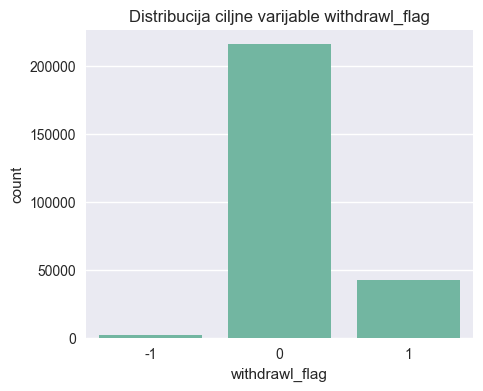

Relativni udjeli klasa:
withdrawl_flag
 0    0.829563
 1    0.164171
-1    0.006266
Name: proportion, dtype: float64


In [5]:
target_col = "withdrawl_flag"

plt.figure(figsize=(5,4))
sns.countplot(x=target_col, data=df)
plt.title("Distribucija ciljne varijable withdrawl_flag")
plt.show()

print("Relativni udjeli klasa:")
print(df[target_col].value_counts(normalize=True))

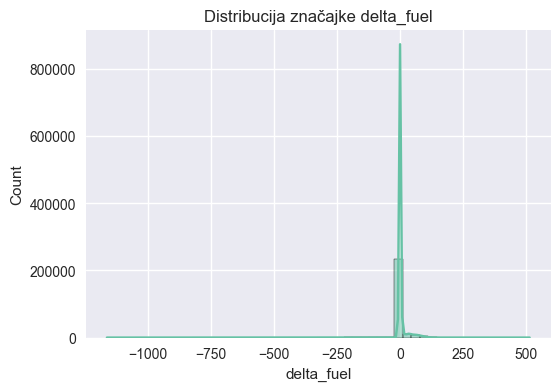

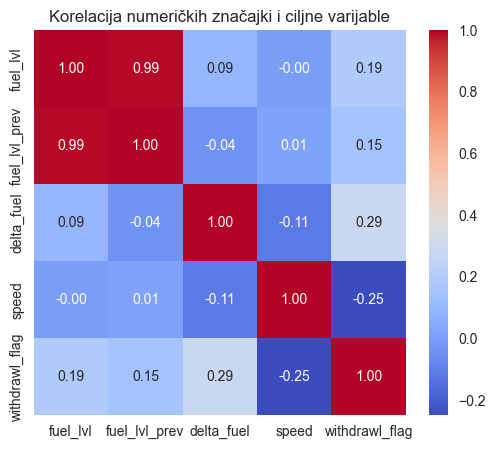

In [9]:
# Filtriraj redove s delta_fuel
df_delta = df.dropna(subset=["delta_fuel"])

plt.figure(figsize=(6,4))
sns.histplot(df_delta["delta_fuel"], bins=50, kde=True)
plt.title("Distribucija značajke delta_fuel")
plt.xlabel("delta_fuel")
plt.show()

num_cols = ["fuel_lvl", "fuel_lvl_prev", "delta_fuel", "speed"]
corr = df_delta[num_cols + [target_col]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelacija numeričkih značajki i ciljne varijable")
plt.show()

### Debalans klasa u ciljnoj varijabli

Vizualizacija raspodjele vrijednosti u `withdrawl_flag` pokazuje da je većina zapisa bez događaja (vrijednost 0), dok je manji broj zapisa s događajem (vrijednost 1).
Takav debalans klasa može dovesti do toga da modeli preferiraju većinsku klasu, stoga pri modeliranju koristimo pristup koji djelomično kompenzira ovaj problem (`class_weight='balanced'` u Random Forestu).
Dodatno, analizirana je distribucija `delta_fuel` te korelacije numeričkih značajki s ciljnom varijablom.

Enkodiranje kategoričke varijable contact_value

In [7]:
from sklearn.preprocessing import LabelEncoder

print(df["contact_value"].value_counts())

le = LabelEncoder()
df["contact_value_encoded"] = le.fit_transform(df["contact_value"].astype(str))

contact_value
Aktivan      143395
Neaktivan     69305
-             47760
Name: count, dtype: int64


In [10]:
print(df["contact_value"].value_counts())

le = LabelEncoder()
df["contact_value_encoded"] = le.fit_transform(df["contact_value"].astype(str))

feature_cols = [
    "fuel_lvl",
    "fuel_lvl_prev",
    "delta_fuel",
    "speed",
    "gps_latitude",
    "gps_longitude",
    "contact_value_encoded"
]

df_model = df_delta.dropna(subset=feature_cols + [target_col])

df_model[feature_cols + [target_col]].head()

contact_value
Aktivan      143395
Neaktivan     69305
-             47760
Name: count, dtype: int64


,fuel_lvl,fuel_lvl_prev,delta_fuel,speed,gps_latitude,gps_longitude,contact_value_encoded,withdrawl_flag
1,88,88.0,0.0,0,46.396875,16.45024,0,0
2,88,88.0,0.0,0,46.396875,16.45024,0,0
3,88,88.0,0.0,0,46.396875,16.45024,0,0
4,88,88.0,0.0,0,46.396875,16.45024,0,0
5,88,88.0,0.0,0,46.396875,16.45024,0,0


### Enkodiranje kategoričke značajke `contact_value`

Stupac `contact_value` predstavlja status kontakta vozila.
Kako bi se mogao koristiti u modelu strojnog učenja, potrebno ga je pretvoriti u numerički oblik.
Primijenjen je Label Encoding, gdje svaka različita kategorija dobiva jedinstveni cijeli broj (`contact_value_encoded`), što omogućava da se ova značajka uključi među ulazne varijable.

Model – Random Forest s rješavanjem debalansa (code)

In [11]:
X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

Confusion matrix:
[[  156   246     6]
 [  211 52715   837]
 [    6  2422  8262]]

Classification report:
              precision    recall  f1-score   support

          -1      0.418     0.382     0.399       408
           0      0.952     0.981     0.966     53763
           1      0.907     0.773     0.835     10690

    accuracy                          0.943     64861
   macro avg      0.759     0.712     0.733     64861
weighted avg      0.941     0.943     0.941     64861



Vizualizacija važnosti značajki:

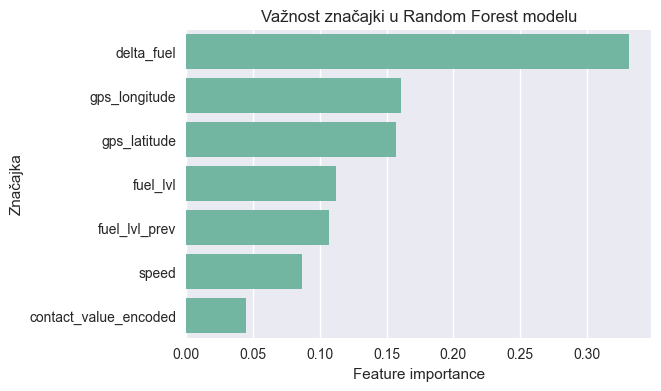

In [ ]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=importances.index)
plt.title("Važnost značajki u Random Forest modelu")
plt.xlabel("Feature importance")
plt.ylabel("Značajka")
plt.show()

### Model predviđanja – Random Forest

Za predviđanje ciljne varijable `withdrawl_flag` korišten je Random Forest classifier.
S obzirom na debalans klasa, model je konfiguriran s parametrom `class_weight='balanced'` te je podjela na skup za učenje i testiranje provedena stratificirano.
Evaluacija na testnom skupu uključuje matricu zabune (confusion matrix) i standardne klasifikacijske metrike (precision, recall, F1) po klasama, kao i prikaz važnosti pojedinih značajki.

Bar-graf raspodjele klasa (pokazuje debalans):

Vizualizacija vremena + labela za jedno vozilo

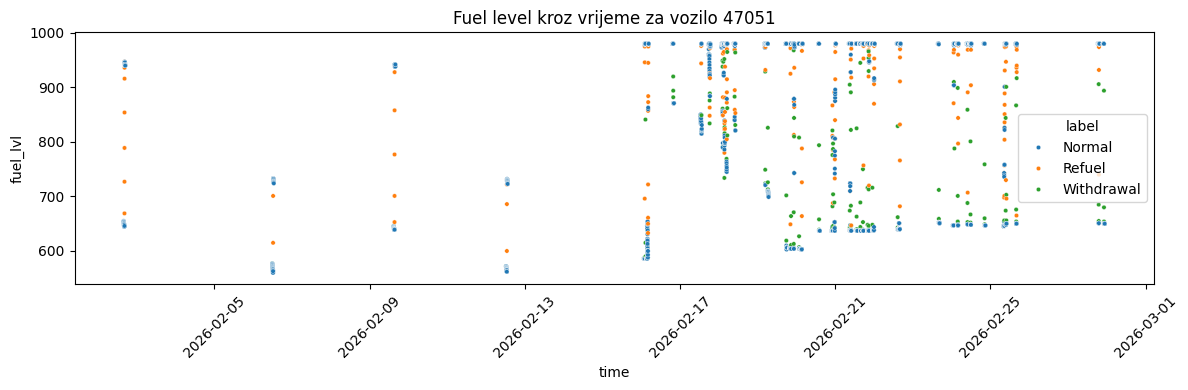

In [ ]:
some_obj = df["obj_id"].value_counts().index[0]
df_obj = df[df["obj_id"] == some_obj]

plt.figure(figsize=(12,4))
sns.scatterplot(
    data=df_obj,
    x="time",
    y="fuel_lvl",
    hue="label",
    s=10
)
plt.title(f"Fuel level kroz vrijeme za vozilo {some_obj}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Analiziran je skup podataka `fuel_data.csv` vezan uz događaje na gorivu vozila.
1. Konstrukcija vremenski ovisne značajke `delta_fuel` koja bolje opisuje promjene razine goriva kroz vrijeme.
2. Debalans klasa u ciljnoj varijabli `withdrawl_flag`  (korištenje `class_weight='balanced'`).

Uz to je provedeno enkodiranje kategoričke varijable `contact_value` pomoću Label Encodera, čime je omogućeno uključivanje te značajke u skup numeričkih ulaznih varijabli.
Vizualizacijom distribucije ciljne varijable, značajke `delta_fuel` i korelacije numeričkih stupaca dobiven je bolji uvid u strukturu podataka.
Konačno, implementiran je Random Forest model koji predviđa `withdrawl_flag` te je evaluiran pomoću klasifikacijskih metrika i analize važnosti značajki, čime su ispunjeni svi traženi elementi zadatka.